# Importing Libraries

In [1]:
## Import modules
import os, sys
import numpy as np
import geopandas as gpd
import cftime
import gc
import shapely
import json
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.colors as pc
from ipywidgets import interact, IntSlider, Dropdown, VBox, HBox
import ipywidgets as widgets

# Add the directory containing 'cmct' to the Python path
# Navigate two levels up to reach main CmCt dir
cmct_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))

# Initialising Logger
import logging

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

# Import utilities for this comparison
sys.path.insert(0, cmct_dir)
from cmct.time_utils import *
from cmct.calving import *
from cmct.calving_modules.interpolation import *
from cmct.calving_modules.residual_calculation import *
# from cmct.calving_modules.json_to_netcdf import *
# from cmct.shapefile_utils import *

# Force initial garbage collection
gc.collect()

40

In [2]:
# Reload modules to pick up any changes to imports
import importlib
import cmct.calving
import cmct.calving_modules.residual_calculation
import cmct.calving_modules.plotting_utils
from cmct.calving_modules.plotting_utils import *
from cmct.calving import calculate_basin_statistics, format_basin_stats
from cmct.calving import calculate_basin_statistics
importlib.reload(cmct.calving)
importlib.reload(cmct.calving_modules.residual_calculation)
importlib.reload(cmct.calving_modules.plotting_utils)

# Re-import to ensure functions are available
from cmct.calving import *

# CONFIGURATION

In [3]:
# Observation Dataset
# Ice sheet
loc = "GIS"  # 'GIS' or 'AIS'

# Set the observation data dir path
obs_filename = cmct_dir + "/data/calving/observed_icemask_ismip_annual.nc"

# To use aggregation functions for basin
basin_aggregation = True  # IMPORTANT

basin_filename = cmct_dir + "/bin/Calving/GRE_Basins_IMBIE2_v1.3/GRE_Basins_IMBIE2_v1.3.shp"

# Set the Model Data dir path
# model_filename = cmct_dir + "/test/calving/ensemble/sftgif_B001_hist.nc"
model_filename = cmct_dir + "/test/calving/sftgif_GIS_JPL_ISSM_historical.nc"

# Set time range for comparison
start_year = 2006
end_year = 2015

# List of basins (ex ["NW", "NE"]) to compare if all -> "all", if none -> False
# If you do not know which basins are in the model, you can put "auto"
# NOTE: Align this list with the basins in the model.
basin_list = "all"

# Output filetype and filename
filetype = "netcdf"  # netcdf or json or None
filename = "calving_comparison"

# Optional Configurations
interpolation_method = "slinear"  # 'nearest', 'linear', 'cubic'
accuracy_calculation_method = "mean"  # 'mean', 'RMS',

colors = {
    "CW": "blue",
    "NE": "red",
    "SE": "green",
    "SW": "orange",
    "NO": "purple",
    "NW": "brown",
}


# Loading all data files

In [4]:
# Check if observation file exist
if not os.path.exists(obs_filename):
    raise FileNotFoundError(f"Observation file not found: {obs_filename}")

# # Check if model file exist
if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Model file not found: {model_filename}")



if basin_aggregation and not os.path.exists(basin_filename):
    raise FileNotFoundError(f"Basin shapefile not found: {basin_filename}")
    # Load basin shapes

print(basin_filename)
basins, basin_list = load_basins(basin_filename, basin_list)

print(obs_filename)
gsfc = load_gsfc_calving(obs_filename, basins)

print(model_filename)
model_res = load_model_calving(model_filename)

/Users/aditya_pachpande/Documents/GitHub/CmCt/bin/Calving/GRE_Basins_IMBIE2_v1.3/GRE_Basins_IMBIE2_v1.3.shp
/Users/aditya_pachpande/Documents/GitHub/CmCt/data/calving/observed_icemask_ismip_annual.nc
/Users/aditya_pachpande/Documents/GitHub/CmCt/test/calving/sftgif_GIS_JPL_ISSM_historical.nc


## Handelling Time Consistency

In [5]:
# Simplifying date data type
gsfc.ds["time"] = standardising_time_var(gsfc.time)
model_res.ds["time"] = standardising_time_var(model_res.time)

# Handelling Time Range
checking_calving_daterange(gsfc.time.values, model_res.time.values, start_year, end_year)


The selected dates 2006 to 2015 are within the overlapping data range.


# Interpolation

In [6]:
interpolater = Interpolater(model_res, gsfc)
model_res.ds = interpolater.interpolate()

2025-07-29 08:33:40,330 - INFO - Input x coordinates: [-720000. -715000. -710000. -705000. -700000. -695000. -690000. -685000.
 -680000. -675000. -670000. -665000. -660000. -655000. -650000. -645000.
 -640000. -635000. -630000. -625000. -620000. -615000. -610000. -605000.
 -600000. -595000. -590000. -585000. -580000. -575000. -570000. -565000.
 -560000. -555000. -550000. -545000. -540000. -535000. -530000. -525000.
 -520000. -515000. -510000. -505000. -500000. -495000. -490000. -485000.
 -480000. -475000. -470000. -465000. -460000. -455000. -450000. -445000.
 -440000. -435000. -430000. -425000. -420000. -415000. -410000. -405000.
 -400000. -395000. -390000. -385000. -380000. -375000. -370000. -365000.
 -360000. -355000. -350000. -345000. -340000. -335000. -330000. -325000.
 -320000. -315000. -310000. -305000. -300000. -295000. -290000. -285000.
 -280000. -275000. -270000. -265000. -260000. -255000. -250000. -245000.
 -240000. -235000. -230000. -225000. -220000. -215000. -210000. -20500

# Comparison and Residual Calculation 

In [7]:
print(type(basins))
years = np.arange(start_year, end_year + 1)

residuals = create_calving_dataset(gsfc, model_res, years, basins)

2025-07-29 08:33:53,986 - INFO - Computing basin mask once for all ensemble members...
2025-07-29 08:33:53,998 - INFO - Transformed basin CW: 1211 points
2025-07-29 08:33:54,037 - INFO - Transformed basin NE: 6780 points
2025-07-29 08:33:54,074 - INFO - Transformed basin SE: 15619 points
2025-07-29 08:33:54,080 - INFO - Transformed basin SW: 4063 points
2025-07-29 08:33:54,086 - INFO - Transformed basin NO: 4016 points
2025-07-29 08:33:54,093 - INFO - Transformed basin NW: 4986 points
2025-07-29 08:33:54,103 - INFO - Grid dimensions: 2880 x 1680
2025-07-29 08:33:54,103 - INFO - Using year 2006 for basin mask creation
2025-07-29 08:33:54,104 - INFO - Creating basin mask...


<class 'dict'>


2025-07-29 08:36:33,076 - INFO - Basin assignment complete. Unique basin IDs: [-1  0  1  2  3  4  5]
2025-07-29 08:36:33,092 - INFO -   Unassigned points: 3112422
2025-07-29 08:36:33,098 - INFO -   Basin 0 (CW): 232302 points
2025-07-29 08:36:33,105 - INFO -   Basin 1 (NE): 478030 points
2025-07-29 08:36:33,135 - INFO -   Basin 2 (SE): 294627 points
2025-07-29 08:36:33,143 - INFO -   Basin 3 (SW): 217562 points
2025-07-29 08:36:33,157 - INFO -   Basin 4 (NO): 232587 points
2025-07-29 08:36:33,167 - INFO -   Basin 5 (NW): 270870 points
2025-07-29 08:36:33,177 - INFO - Basin assignment rate: 1725978/4838400 (35.7%)
2025-07-29 08:36:33,179 - INFO - Creating calving dataset with precomputed basin mask...
2025-07-29 08:36:36,234 - INFO - GSFC data shape: (10, 2880, 1680)
2025-07-29 08:36:43,024 - INFO - Model data shape after alignment: (10, 2880, 1680)
2025-07-29 08:36:43,027 - INFO - Basin mask shape: (2880, 1680)
2025-07-29 08:36:43,028 - INFO - Computing residuals...
2025-07-29 08:36:43

In [8]:
residuals = load_residuals(residuals)


In [9]:
vars(residuals)


{'ds': <xarray.Dataset> Size: 774MB
 Dimensions:                 (time: 10, y: 2880, x: 1680, basin_id: 6)
 Coordinates:
   * time                    (time) int64 80B 2006 2007 2008 ... 2013 2014 2015
   * x                       (x) float32 7kB -7.195e+05 -7.185e+05 ... 9.595e+05
   * y                       (y) float32 12kB -3.45e+06 -3.448e+06 ... -5.705e+05
     basin_names             (basin_id) <U2 48B 'CW' 'NE' 'SE' 'SW' 'NO' 'NW'
 Dimensions without coordinates: basin_id
 Data variables:
     residual                (time, y, x) float32 194MB 0.0 0.0 0.0 ... 0.0 0.0
     basin                   (time, y, x) int32 194MB -1 -1 -1 -1 ... -1 -1 -1 -1
     gsfc_ice_mask           (time, y, x) float32 194MB 0.0 0.0 0.0 ... 0.0 0.0
     model_ice_mask          (time, y, x) float32 194MB 0.0 0.0 0.0 ... 0.0 0.0
     stats_avg_abs_residual  (time) float64 80B 0.02461 0.02462 ... 0.02482
     stats_rms_residual      (time) float64 80B 0.1319 0.1319 ... 0.1326 0.1327
     stats_sum_residu

# Statistics Calculation

In [10]:
basin_stats = calculate_basin_statistics(residuals)
print(format_basin_stats(basin_stats))

2025-07-28 23:28:37,785 - INFO - Starting basin statistics calculation
2025-07-28 23:28:37,786 - INFO - Processing 10 time steps and 6 basins
2025-07-28 23:28:39,469 - INFO - Basin statistics calculation completed


=== Statistics for Year 2006 ===
Basin | Sum       | Count    | Mean        | Winsorized  | Outlier Wgt | Std        | RMS
-------------------------------------------------------------------------------------
CW    | 23.257492065429688 |   232302 |  0.00010012 |  0.00013375 |  0.00004944 |   0.036565 |   0.036565
NE    | -2797.58154296875 |   478030 | -0.00585231 | -0.00666378 | -0.00003793 |   0.115760 |   0.115908
SE    | 14.06719970703125 |   294627 |  0.00004775 | -0.00724717 | -0.00024722 |   0.204647 |   0.204647
SW    | 1017.2067260742188 |   217562 |  0.00467548 |  0.00493314 |  0.00028247 |   0.081600 |   0.081734
NO    | 2110.669189453125 |   232587 |  0.00907475 |  0.00970253 |  0.00030426 |   0.115014 |   0.115371
NW    | -181.97161865234375 |   270870 | -0.00067180 | -0.00062181 |  0.00009068 |   0.060439 |   0.060443
-------------------------------------------------------------------------------------


=== Statistics for Year 2007 ===
Basin | Sum       | Count    | Mean 

# Plot Generation

## Configuration
- residuals are required for plot generation

In [11]:
# Import plotting functions from plotting_utils
from cmct.calving_modules.plotting_utils import (
    create_time_series_plot,
    create_relative_time_series_plot,
    create_gsfc_model_residual_grid,
    create_correlation_matrix,
)

# Which year do you want plots for?
year = 2007

cmap = "ocean"  # Leave default to Ocean :)
aspect = "auto"

# Plot config
plt.figure(figsize=(10, 6))
basin_id = 0
# plt.cm.viridis.set_bad('lightblue')  # Set color for NaN values

<Figure size 1000x600 with 0 Axes>

# Interactive Plotting Analysisdd

# Correlation Analysis

In [20]:
# Examine data structures
print("GSFC data structure:")
print(f"GSFC variables: {list(gsfc.ds.data_vars)}")
print(f"GSFC coordinates: x={gsfc.x.min().values:.1f} to {gsfc.x.max().values:.1f}, y={gsfc.y.min().values:.1f} to {gsfc.y.max().values:.1f}")

print("\nModel data structure:")
print(f"Model variables: {list(model_res.ds.data_vars)}")
print(f"Model coordinates: x={model_res.x.min().values:.1f} to {model_res.x.max().values:.1f}, y={model_res.y.min().values:.1f} to {model_res.y.max().values:.1f}")

print("\nResiduals data structure:")
print(f"Residuals variables: {list(residuals.ds.data_vars)}")
print(f"Residuals coordinates: x={residuals.ds.x.min().values:.1f} to {residuals.ds.x.max().values:.1f}, y={residuals.ds.y.min().values:.1f} to {residuals.ds.y.max().values:.1f}")

# Check coordinate spacing
print(f"\nCoordinate spacing:")
print(f"GSFC x spacing: {(gsfc.x[1] - gsfc.x[0]).values}")
print(f"GSFC y spacing: {(gsfc.y[1] - gsfc.y[0]).values}")
print(f"Model x spacing: {(model_res.x[1] - model_res.x[0]).values}")
print(f"Model y spacing: {(model_res.y[1] - model_res.y[0]).values}")

GSFC data structure:
GSFC variables: ['ice_mask']
GSFC coordinates: x=-719500.0 to 959500.0, y=-3449500.0 to -570500.0

Model data structure:
Model variables: ['lon_bnds', 'lat_bnds', 'ice_mask']
Model coordinates: x=-719500.0 to 959500.0, y=-3449500.0 to -570500.0

Residuals data structure:
Residuals variables: ['residual', 'basin', 'gsfc_ice_mask', 'model_ice_mask', 'stats_avg_abs_residual', 'stats_rms_residual', 'stats_sum_residual', 'stats_valid_points', 'stats_total_points']
Residuals coordinates: x=-719500.0 to 959500.0, y=-3449500.0 to -570500.0

Coordinate spacing:
GSFC x spacing: 1000.0
GSFC y spacing: 1000.0
Model x spacing: 1000.0
Model y spacing: 1000.0


In [21]:
# Target coordinates
target_x = 579.5 * 1000  # Convert km to meters
target_y = -1967.5 * 1000  # Convert km to meters

print(f"Target coordinates: x={target_x}, y={target_y}")

# Find the nearest grid points
x_idx = abs(gsfc.x - target_x).argmin()
y_idx = abs(gsfc.y - target_y).argmin()

actual_x = gsfc.x[x_idx].values
actual_y = gsfc.y[y_idx].values

print(f"Nearest grid point: x={actual_x}, y={actual_y}")
print(f"Grid indices: x_idx={x_idx}, y_idx={y_idx}")

# Extract time series data at the specified location
gsfc_data = gsfc.ds.ice_mask[:, y_idx, x_idx]
model_data = model_res.ds.ice_mask[:, y_idx, x_idx]
residual_data = residuals.ds.residual[:, y_idx, x_idx]

print(f"\nData shapes:")
print(f"GSFC data: {gsfc_data.shape}")
print(f"Model data: {model_data.shape}")
print(f"Residual data: {residual_data.shape}")

# Get time coordinates
time_values = gsfc.ds.time.values

print(f"\nTime range: {time_values[0]} to {time_values[-1]}")
print(f"Number of time steps: {len(time_values)}")

Target coordinates: x=579500.0, y=-1967500.0
Nearest grid point: x=579500.0, y=-1967500.0
Grid indices: x_idx=<xarray.DataArray 'x' ()> Size: 8B
array(1299), y_idx=<xarray.DataArray 'y' ()> Size: 8B
array(1482)

Data shapes:
GSFC data: (49,)
Model data: (36,)
Residual data: (10,)

Time range: 1973.0 to 2021.0
Number of time steps: 49


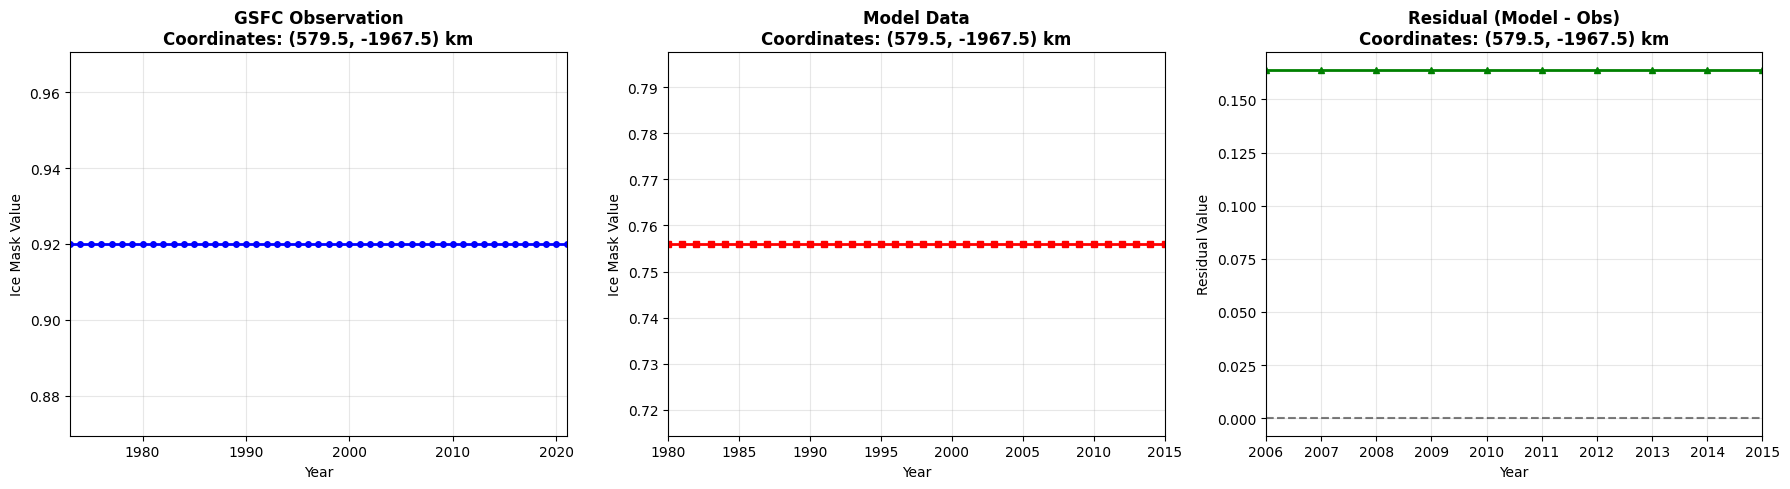


Summary Statistics at coordinates (579.5, -1967.5) km:
GSFC Observation:
  Mean: 0.9200
  Std: 0.0000
  Range: 0.9200 to 0.9200

Model Data:
  Mean: 0.7560
  Std: 0.0000
  Range: 0.7560 to 0.7560

Residual Data:
  Mean: 0.1640
  Std: 0.0000
  Range: 0.1640 to 0.1640
  RMS: 0.1640


In [12]:
# Create three-panel plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: GSFC Observation Data
gsfc_time = gsfc.ds.time.values
gsfc_values = gsfc_data.values
axes[0].plot(gsfc_time, gsfc_values, 'b-', linewidth=2, marker='o', markersize=4)
axes[0].set_title(f'GSFC Observation\nCoordinates: ({actual_x/1000:.1f}, {actual_y/1000:.1f}) km', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Ice Mask Value')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(gsfc_time.min(), gsfc_time.max())

# Panel 2: Model Data  
model_time = model_res.ds.time.values
model_values = model_data.values
axes[1].plot(model_time, model_values, 'r-', linewidth=2, marker='s', markersize=4)
axes[1].set_title(f'Model Data\nCoordinates: ({actual_x/1000:.1f}, {actual_y/1000:.1f}) km', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Ice Mask Value')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(model_time.min(), model_time.max())

# Panel 3: Residual Data
residual_time = residuals.ds.time.values
residual_values = residual_data.values
axes[2].plot(residual_time, residual_values, 'g-', linewidth=2, marker='^', markersize=4)
axes[2].set_title(f'Residual (Model - Obs)\nCoordinates: ({actual_x/1000:.1f}, {actual_y/1000:.1f}) km', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Residual Value')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[2].set_xlim(residual_time.min(), residual_time.max())

# Adjust layout
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary Statistics at coordinates ({actual_x/1000:.1f}, {actual_y/1000:.1f}) km:")
print(f"GSFC Observation:")
print(f"  Mean: {gsfc_values.mean():.4f}")
print(f"  Std: {gsfc_values.std():.4f}")
print(f"  Range: {gsfc_values.min():.4f} to {gsfc_values.max():.4f}")

print(f"\nModel Data:")
print(f"  Mean: {model_values.mean():.4f}")
print(f"  Std: {model_values.std():.4f}")
print(f"  Range: {model_values.min():.4f} to {model_values.max():.4f}")

print(f"\nResidual Data:")
print(f"  Mean: {residual_values.mean():.4f}")
print(f"  Std: {residual_values.std():.4f}")
print(f"  Range: {residual_values.min():.4f} to {residual_values.max():.4f}")
print(f"  RMS: {np.sqrt(np.mean(residual_values**2)):.4f}")

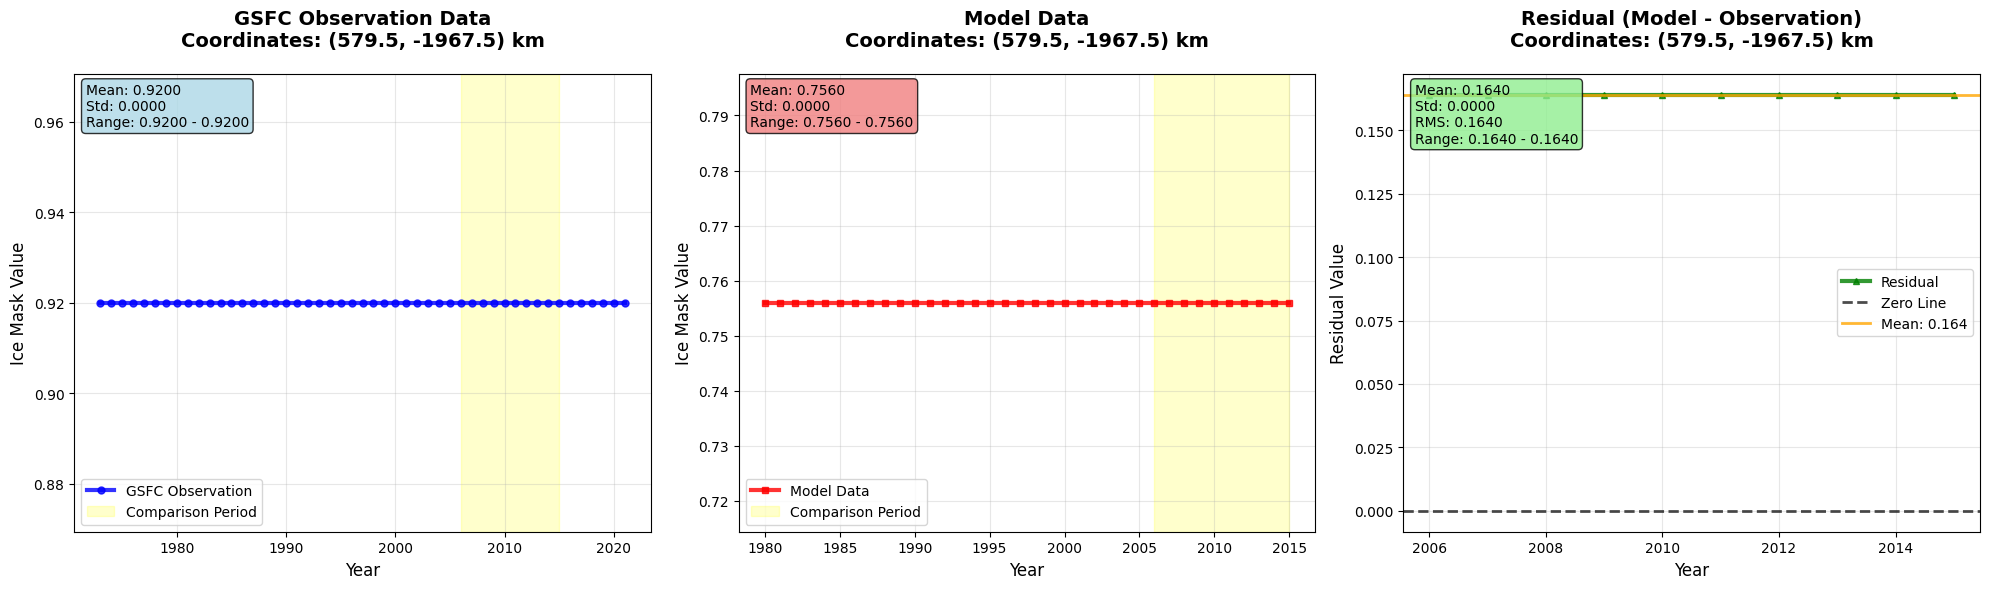

DETAILED ANALYSIS AT COORDINATES (579.5, -1967.5) km
Grid Position: x_index=1299, y_index=1482
Actual Grid Coordinates: x=579500.0m, y=-1967500.0m

DATA COMPARISON:
----------------------------------------
GSFC Observation (1973-2021): 49 time points
  Value: 0.920000 (constant)
  Time span: 1973 - 2021

Model Data (1980-2015): 36 time points
  Value: 0.755993 (constant)
  Time span: 1980 - 2015

Residual Data (2006-2015): 10 time points
  Mean residual: 0.164007
  RMS residual: 0.164007
  Time span: 2006 - 2015

INTERPRETATION:
----------------------------------------
- Significant residual indicates model-observation disagreement
- Positive residual: Model predicts higher ice mask values than observed


In [22]:
# Create a comprehensive three-panel comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: GSFC Observation Data with enhanced styling
axes[0].plot(gsfc_time, gsfc_values, 'b-', linewidth=3, marker='o', markersize=5, alpha=0.8, label='GSFC Observation')
axes[0].axvspan(start_year, end_year, alpha=0.2, color='yellow', label='Comparison Period')
axes[0].set_title(f'GSFC Observation Data\nCoordinates: ({actual_x/1000:.1f}, {actual_y/1000:.1f}) km', 
                  fontsize=14, fontweight='bold', pad=20)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Ice Mask Value', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)
axes[0].tick_params(labelsize=10)

# Add statistics text
axes[0].text(0.02, 0.98, f'Mean: {gsfc_values.mean():.4f}\nStd: {gsfc_values.std():.4f}\nRange: {gsfc_values.min():.4f} - {gsfc_values.max():.4f}',
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Panel 2: Model Data with enhanced styling
axes[1].plot(model_time, model_values, 'r-', linewidth=3, marker='s', markersize=5, alpha=0.8, label='Model Data')
axes[1].axvspan(start_year, end_year, alpha=0.2, color='yellow', label='Comparison Period')
axes[1].set_title(f'Model Data\nCoordinates: ({actual_x/1000:.1f}, {actual_y/1000:.1f}) km', 
                  fontsize=14, fontweight='bold', pad=20)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Ice Mask Value', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)
axes[1].tick_params(labelsize=10)

# Add statistics text
axes[1].text(0.02, 0.98, f'Mean: {model_values.mean():.4f}\nStd: {model_values.std():.4f}\nRange: {model_values.min():.4f} - {model_values.max():.4f}',
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

# Panel 3: Residual Data with enhanced styling
axes[2].plot(residual_time, residual_values, 'g-', linewidth=3, marker='^', markersize=5, alpha=0.8, label='Residual')
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.7, linewidth=2, label='Zero Line')
axes[2].axhline(y=residual_values.mean(), color='orange', linestyle='-', alpha=0.8, 
                linewidth=2, label=f'Mean: {residual_values.mean():.3f}')
axes[2].set_title(f'Residual (Model - Observation)\nCoordinates: ({actual_x/1000:.1f}, {actual_y/1000:.1f}) km', 
                  fontsize=14, fontweight='bold', pad=20)
axes[2].set_xlabel('Year', fontsize=12)
axes[2].set_ylabel('Residual Value', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=10)
axes[2].tick_params(labelsize=10)

# Add statistics text
rms_value = np.sqrt(np.mean(residual_values**2))
axes[2].text(0.02, 0.98, f'Mean: {residual_values.mean():.4f}\nStd: {residual_values.std():.4f}\nRMS: {rms_value:.4f}\nRange: {residual_values.min():.4f} - {residual_values.max():.4f}',
             transform=axes[2].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Adjust layout
plt.tight_layout()
plt.show()

# Print detailed analysis
print("="*80)
print(f"DETAILED ANALYSIS AT COORDINATES ({actual_x/1000:.1f}, {actual_y/1000:.1f}) km")
print("="*80)
print(f"Grid Position: x_index={x_idx.values}, y_index={y_idx.values}")
print(f"Actual Grid Coordinates: x={actual_x:.1f}m, y={actual_y:.1f}m")
print()
print("DATA COMPARISON:")
print("-" * 40)
print(f"GSFC Observation (1973-2021): {len(gsfc_time)} time points")
print(f"  Value: {gsfc_values.mean():.6f} (constant)")
print(f"  Time span: {gsfc_time.min():.0f} - {gsfc_time.max():.0f}")
print()
print(f"Model Data (1980-2015): {len(model_time)} time points") 
print(f"  Value: {model_values.mean():.6f} (constant)")
print(f"  Time span: {model_time.min():.0f} - {model_time.max():.0f}")
print()
print(f"Residual Data (2006-2015): {len(residual_time)} time points")
print(f"  Mean residual: {residual_values.mean():.6f}")
print(f"  RMS residual: {rms_value:.6f}")
print(f"  Time span: {residual_time.min():.0f} - {residual_time.max():.0f}")
print()
print("INTERPRETATION:")
print("-" * 40)
if abs(residual_values.mean()) < 0.1:
    print("- Small residual indicates good model-observation agreement")
else:
    print("- Significant residual indicates model-observation disagreement")
    
if residual_values.mean() > 0:
    print("- Positive residual: Model predicts higher ice mask values than observed")
else:
    print("- Negative residual: Model predicts lower ice mask values than observed")
print("="*80)

In [ ]:
# Create Plotly spatial visualization for year 2010
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Select year 2010 data
target_year = 2006

# Find the time index for 2010
gsfc_time_idx = np.argmin(np.abs(gsfc.ds.time.values - target_year))
model_time_idx = np.argmin(np.abs(model_res.ds.time.values - target_year))
residual_time_idx = np.argmin(np.abs(residuals.ds.time.values - target_year))

print(f"Selected year: {target_year}")
print(f"GSFC actual year: {gsfc.ds.time.values[gsfc_time_idx]}")
print(f"Model actual year: {model_res.ds.time.values[model_time_idx]}")
print(f"Residual actual year: {residuals.ds.time.values[residual_time_idx]}")

# Extract 2D spatial data for 2010
gsfc_2010 = gsfc.ds.ice_mask[gsfc_time_idx, :, :].values
model_2010 = model_res.ds.ice_mask[model_time_idx, :, :].values  
residual_2010 = residuals.ds.residual[residual_time_idx, :, :].values

# Get coordinate arrays (convert to km for display)
x_coords = gsfc.ds.x.values / 1000  # Convert to km
y_coords = gsfc.ds.y.values / 1000  # Convert to km

print(f"\nData shapes:")
print(f"X coordinates: {x_coords.shape} (range: {x_coords.min():.1f} to {x_coords.max():.1f} km)")
print(f"Y coordinates: {y_coords.shape} (range: {y_coords.min():.1f} to {y_coords.max():.1f} km)")
print(f"GSFC 2010: {gsfc_2010.shape}")
print(f"Model 2010: {model_2010.shape}")
print(f"Residual 2010: {residual_2010.shape}")

# Create subplots
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=['GSFC Observation ' + str(target_year), 'Model Data ' + str(target_year), 'Residual (Model - Obs) ' + str(target_year)],
    horizontal_spacing=0.05
)

# Panel 1: GSFC Observation
fig.add_trace(
    go.Heatmap(
        z=gsfc_2010,
        x=x_coords,
        y=y_coords,
        colorscale='Blues',
        name='GSFC',
        hovertemplate='X: %{x:.1f} km<br>Y: %{y:.1f} km<br>Ice Mask: %{z:.3f}<extra></extra>',
        colorbar=dict(
            title=dict(text="Ice Mask Value"),
            thickness=15,
            len=0.9,
            x=0.31
        )
    ),
    row=1, col=1
)

# Panel 2: Model Data
fig.add_trace(
    go.Heatmap(
        z=model_2010,
        x=x_coords,
        y=y_coords,
        colorscale='Reds',
        name='Model',
        hovertemplate='X: %{x:.1f} km<br>Y: %{y:.1f} km<br>Ice Mask: %{z:.3f}<extra></extra>',
        colorbar=dict(
            title=dict(text="Ice Mask Value"),
            thickness=15,
            len=0.9,
            x=0.645
        )
    ),
    row=1, col=2
)

# Panel 3: Residual Data
fig.add_trace(
    go.Heatmap(
        z=residual_2010,
        x=x_coords,
        y=y_coords,
        colorscale='RdBu_r',
        name='Residual',
        hovertemplate='X: %{x:.1f} km<br>Y: %{y:.1f} km<br>Residual: %{z:.3f}<extra></extra>',
        colorbar=dict(
            title=dict(text="Residual Value"),
            thickness=15,
            len=0.9,
            x=1.02
        )
    ),
    row=1, col=3
)

# Add marker for target coordinates
target_x_km = target_x / 1000
target_y_km = target_y / 1000

for col in range(1, 4):
    fig.add_trace(
        go.Scatter(
            x=[target_x_km],
            y=[target_y_km],
            mode='markers',
            marker=dict(
                size=12,
                color='yellow',
                symbol='star',
                line=dict(color='black', width=2)
            ),
            name='Target Point',
            showlegend=(col == 1),
            hovertemplate=f'Target: ({target_x_km:.1f}, {target_y_km:.1f}) km<extra></extra>'
        ),
        row=1, col=col
    )

# Update layout
fig.update_layout(
    title=dict(
        text=f'Spatial Distribution of Ice Mask Data for Year {target_year}',
        x=0.5,
        font=dict(size=16, family="Arial Black")
    ),
    width=1400,
    height=500,
    font=dict(size=11),
    margin=dict(l=50, r=50, t=80, b=50)
)

# Update axes for all subplots
for i in range(1, 4):
    fig.update_xaxes(title_text="X Coordinate (km)", row=1, col=i)
    fig.update_yaxes(title_text="Y Coordinate (km)", row=1, col=i)

# Show the plot
fig.show()

# Print statistics for the spatial data
print(f"\nSpatial Statistics for Year {target_year}:")
print("="*50)
print(f"GSFC Observation:")
print(f"  Min: {np.nanmin(gsfc_2010):.4f}")
print(f"  Max: {np.nanmax(gsfc_2010):.4f}")
print(f"  Mean: {np.nanmean(gsfc_2010):.4f}")
print(f"  Valid points: {np.sum(~np.isnan(gsfc_2010))}")

print(f"\nModel Data:")
print(f"  Min: {np.nanmin(model_2010):.4f}")
print(f"  Max: {np.nanmax(model_2010):.4f}")
print(f"  Mean: {np.nanmean(model_2010):.4f}")
print(f"  Valid points: {np.sum(~np.isnan(model_2010))}")

print(f"\nResidual Data:")
print(f"  Min: {np.nanmin(residual_2010):.4f}")
print(f"  Max: {np.nanmax(residual_2010):.4f}")
print(f"  Mean: {np.nanmean(residual_2010):.4f}")
print(f"  RMS: {np.sqrt(np.nanmean(residual_2010**2)):.4f}")
print(f"  Valid points: {np.sum(~np.isnan(residual_2010))}")

# Value at target coordinates
print(f"\nValues at target coordinates ({target_x_km:.1f}, {target_y_km:.1f}) km:")
print(f"  GSFC: {gsfc_2010[y_idx, x_idx]:.4f}")
print(f"  Model: {model_2010[y_idx, x_idx]:.4f}")
print(f"  Residual: {residual_2010[y_idx, x_idx]:.4f}")

Selected year: 2006
GSFC actual year: 2006.0
Model actual year: 2006.0
Residual actual year: 2006

Data shapes:
X coordinates: (1680,) (range: -719.5 to 959.5 km)
Y coordinates: (2880,) (range: -3449.5 to -570.5 km)
GSFC 2010: (2880, 1680)
Model 2010: (2880, 1680)
Residual 2010: (2880, 1680)


In [37]:
# Simple zoom to show 3 squares
print("Creating zoomed view with 3 squares...")

# Define zoom region - left side of Greenland
x_center_km = -290
y_center_km = -1910
zoom_pixels = 150

# Convert to indices
x_center_idx = np.argmin(np.abs(x_coords - x_center_km))
y_center_idx = np.argmin(np.abs(y_coords - y_center_km))

# Calculate zoom bounds
x_start = max(0, x_center_idx - zoom_pixels // 2)
x_end = min(len(x_coords), x_center_idx + zoom_pixels // 2)
y_start = max(0, y_center_idx - zoom_pixels // 2)
y_end = min(len(y_coords), y_center_idx + zoom_pixels // 2)

# Extract zoomed data
gsfc_zoom = gsfc_2010[y_start:y_end, x_start:x_end]
model_zoom = model_2010[y_start:y_end, x_start:x_end]
residual_zoom = residual_2010[y_start:y_end, x_start:x_end]
x_zoom = x_coords[x_start:x_end]
y_zoom = y_coords[y_start:y_end]

print(
    f"Zoom region: {x_zoom[0]:.1f} to {x_zoom[-1]:.1f} km (X), {y_zoom[0]:.1f} to {y_zoom[-1]:.1f} km (Y)"
)

# Create 3 squares
fig_zoom = make_subplots(rows=1, cols=3, subplot_titles=["GSFC " + str(target_year), "Model " + str(target_year), "Residual " + str(target_year)])

# GSFC square
fig_zoom.add_trace(
    go.Heatmap(z=gsfc_zoom, x=x_zoom, y=y_zoom, colorscale="Blues", showscale=False),
    row=1,
    col=1,
)

# Model square
fig_zoom.add_trace(
    go.Heatmap(z=model_zoom, x=x_zoom, y=y_zoom, colorscale="Reds", showscale=False),
    row=1,
    col=2,
)

# Residual square
fig_zoom.add_trace(
    go.Heatmap(z=residual_zoom, x=x_zoom, y=y_zoom, colorscale="RdBu", showscale=True),
    row=1,
    col=3,
)

# Update layout with axis labels
fig_zoom.update_layout(title="Zoomed View: 3 Squares", width=1200, height=400)

# Add axis labels to all subplots
fig_zoom.update_xaxes(title_text="X (km)")
fig_zoom.update_yaxes(title_text="Y (km)")

fig_zoom.show()

print(
    "Complete! 3 squares showing GSFC, Model, and Residual data with proper axis labels."
)


Creating zoomed view with 3 squares...
Zoom region: -365.5 to -216.5 km (X), -1985.5 to -1836.5 km (Y)


Complete! 3 squares showing GSFC, Model, and Residual data with proper axis labels.
